In [2]:
!pip install pymupdf python-docx pytesseract scikit-learn shap matplotlib seaborn xgboost lightgbm streamlit

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# ============================================================
# STEP 2 — IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import re
import os
import pickle
import joblib
import json
from sklearn.metrics.pairwise import cosine_similarity
# PDF reading
import fitz                          # pymupdf

# DOCX reading
import docx

# OCR for image resumes
import pytesseract
from PIL import Image

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Explainable AI
import shap

In [4]:
# ============================================================
# STEP 3 — TARGET JOB ROLES
# ============================================================

TARGET_ROLES = [
    "Data Scientist",
    "Machine Learning Engineer",
    "Data Analyst",
    "Software Engineer",
]

In [5]:
df = pd.read_csv("Downloads/job_applicant_dataset.csv")

In [6]:
print(df.shape)
df.head()

# In the dataset, the "Data Scientist" role is not directly available —
# the "AI Researcher" role has similar skills to Data Scientist,
# so we are renaming it for consistency.

df["Job Roles"] = df["Job Roles"].replace({"AI Researcher": "Data Scientist"})

# Reset index after preprocessing
df = df.reset_index(drop=True)

print("Dataset shape:", df.shape)
print("\nJob role distribution:")
print(df["Job Roles"].value_counts())
print("\nColumns:", df.columns.tolist())
df.head()

(10000, 9)
Dataset shape: (10000, 9)

Job role distribution:
Job Roles
Personal Trainer                   226
Urban Planner                      220
Biomedical Engineer                220
Construction Manager               215
Robotics Engineer                  214
Mechanical Engineer                214
Operations Manager                 209
Pilot                              209
Machine Learning Engineer          208
Web Developer                      207
Financial Analyst                  206
Systems Analyst                    203
Environmental Scientist            203
Creative Director                  203
Chef                               202
Data Analyst                       202
Physician                          201
Data Scientist                     201
HR Specialist                      201
Event Planner                      201
Supply Chain Manager               199
Civil Engineer                     199
Accountant                         199
Sales Representative            

,Job Applicant Name,Age,Gender,Race,Ethnicity,Resume,Job Roles,Job Description,Best Match
0,Daisuke Mori,29,Male,Mongoloid/Asian,Vietnamese,"Proficient in Injury Prevention, Motivation, N...",Fitness Coach,A Fitness Coach is responsible for helping cl...,0
1,Taichi Shimizu,31,Male,Mongoloid/Asian,Filipino,"Proficient in Healthcare, Pharmacology, Medica...",Physician,"Diagnose and treat illnesses, prescribe medica...",0
2,Sarah Martin,46,Female,White/Caucasian,Dutch,"Proficient in Forecasting, Financial Modelling...",Financial Analyst,"As a Financial Analyst, you will be responsibl...",0
3,Keith Hughes,43,Male,Negroid/Black,Caribbean,"Proficient in Budgeting, Supply Chain Optimiza...",Supply Chain Manager,A Supply Chain Manager oversees the entire sup...,1
4,James Davis,49,Male,White/Caucasian,English,"Proficient in Logistics, Negotiation, Procurem...",Supply Chain Manager,A Supply Chain Manager oversees the entire sup...,1


In [7]:
# ============================================================
# STEP 5 — TEXT CLEANING
# ============================================================

# Custom stopwords
STOP_WORDS = {
    "a","an","the","and","or","but","in","on","at","to","for","of","with",
    "is","are","was","were","be","been","being","have","has","had","do","does",
    "did","will","would","could","should","may","might","shall","can","need",
    "it","its","this","that","these","those","i","we","you","he","she","they",
    "my","our","your","his","her","their","as","by","from","up","about","into",
    "through","during","before","after","above","below","between","each","all",
    "also","such","well","just","very","more","most","some","any","both","few",
}

def clean_text(text):
    """Resume text clean karta hai"""
    if pd.isnull(text):
        return ""
    text = text.lower()                          # lowercase
    text = re.sub(r"[^a-zA-Z\s]", "", text)     # special chars / numbers remove
    words = text.split()
    words = [w for w in words if w not in STOP_WORDS]
    return " ".join(words)

df["clean_resume"] = df["Resume"].apply(clean_text)
df["clean_jd"]     = df["Job Description"].apply(clean_text)

print("Text cleaning done.")
print(df[["Job Roles", "clean_resume"]].head(3))


Text cleaning done.
           Job Roles                                       clean_resume
0      Fitness Coach  proficient injury prevention motivation nutrit...
1          Physician  proficient healthcare pharmacology medical ter...
2  Financial Analyst  proficient forecasting financial modelling exc...


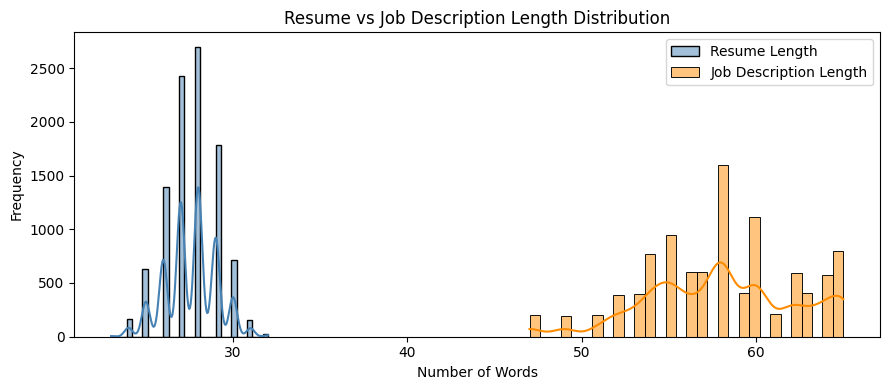

C:\Users\PMYLS\AppData\Local\Temp\ipykernel_22496\2861935129.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette="magma")


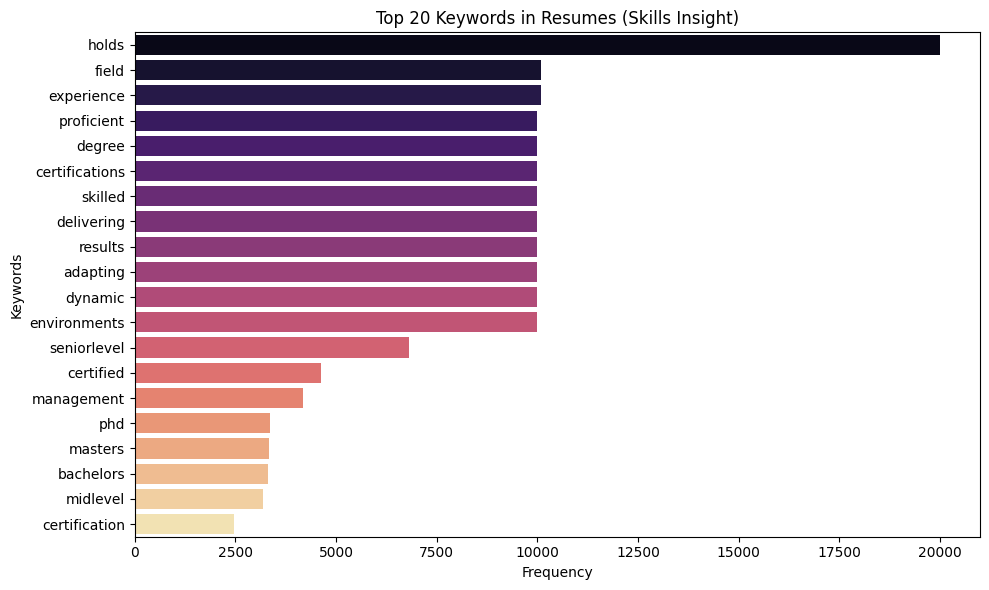

C:\Users\PMYLS\AppData\Local\Temp\ipykernel_22496\2861935129.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette="viridis")


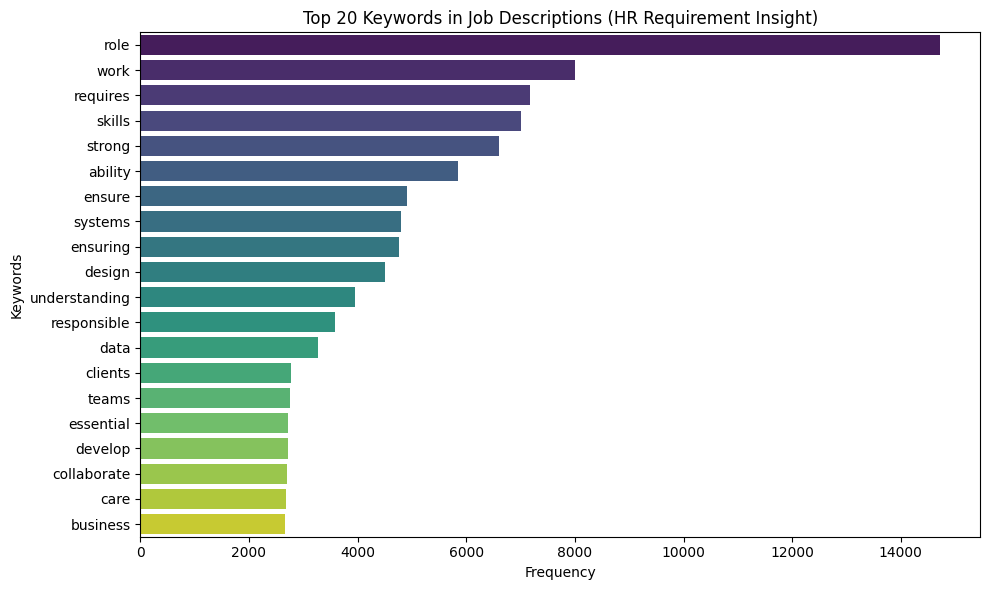

C:\Users\PMYLS\AppData\Local\Temp\ipykernel_22496\2861935129.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


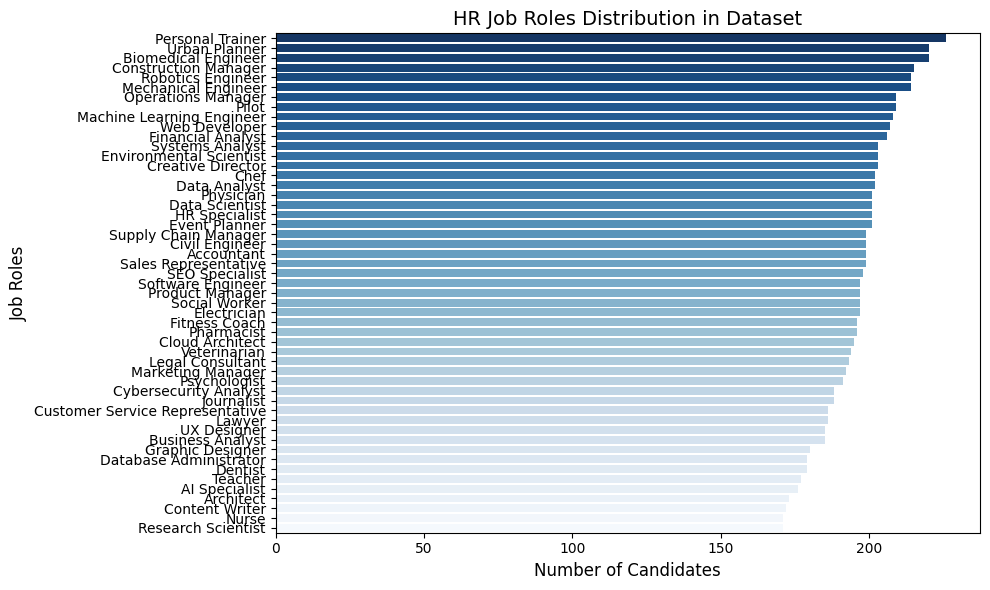

C:\Users\PMYLS\AppData\Local\Temp\ipykernel_22496\2861935129.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


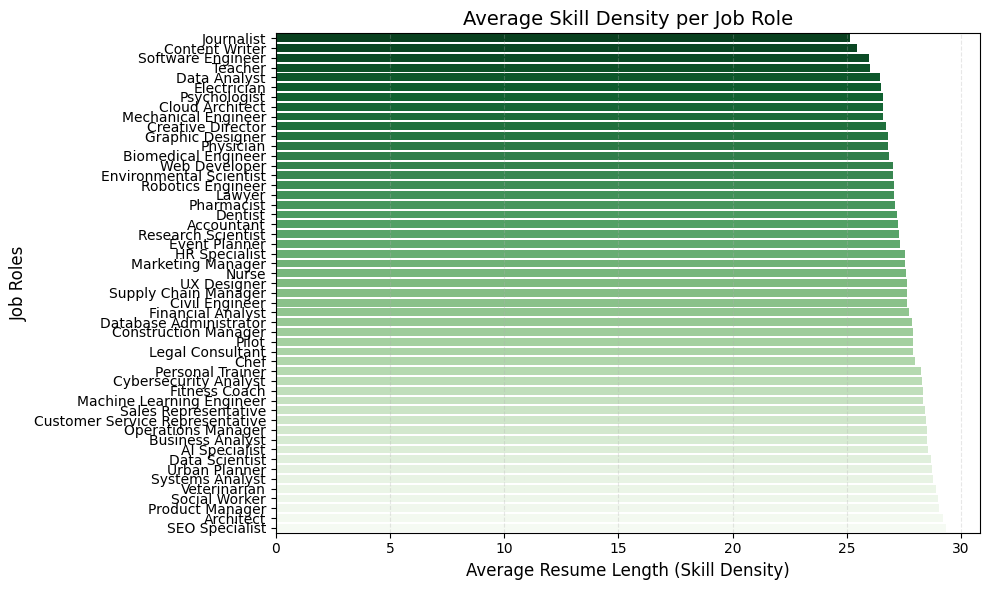


===== HR INSIGHTS SUMMARY =====
Total Candidates: 10000

Job Role Distribution:
Job Roles
Personal Trainer                   226
Urban Planner                      220
Biomedical Engineer                220
Construction Manager               215
Robotics Engineer                  214
Mechanical Engineer                214
Operations Manager                 209
Pilot                              209
Machine Learning Engineer          208
Web Developer                      207
Financial Analyst                  206
Systems Analyst                    203
Environmental Scientist            203
Creative Director                  203
Chef                               202
Data Analyst                       202
Physician                          201
Data Scientist                     201
HR Specialist                      201
Event Planner                      201
Supply Chain Manager               199
Civil Engineer                     199
Accountant                         199
Sales Repres

In [8]:
# ============================================================
# STEP 6 — IMPROVED EDA (HR Recommendation System VERSION)
# ============================================================

# -------------------------------
# 1. Basic Length Features
# -------------------------------
df["resume_length"] = df["clean_resume"].apply(lambda x: len(x.split()))
df["jd_length"]     = df["clean_jd"].apply(lambda x: len(x.split()))

# -------------------------------
# 2. Resume vs JD Length Distribution
# -------------------------------
plt.figure(figsize=(9, 4))
sns.histplot(df["resume_length"], bins=30, kde=True,
             color="steelblue", label="Resume Length")
sns.histplot(df["jd_length"], bins=30, kde=True,
             color="darkorange", label="Job Description Length")

plt.legend()
plt.title("Resume vs Job Description Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# -------------------------------
# 3. Top Keywords in Resumes
# -------------------------------
from collections import Counter

all_resume_text = " ".join(df["clean_resume"])
resume_counts = Counter(all_resume_text.split()).most_common(20)
words, counts = zip(*resume_counts)

plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts), y=list(words), palette="magma")
plt.title("Top 20 Keywords in Resumes (Skills Insight)")
plt.xlabel("Frequency")
plt.ylabel("Keywords")
plt.tight_layout()
plt.show()

# -------------------------------
# 4. Top Keywords in Job Descriptions
# -------------------------------
all_jd_text = " ".join(df["clean_jd"])
jd_counts = Counter(all_jd_text.split()).most_common(20)
words, counts = zip(*jd_counts)

plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts), y=list(words), palette="viridis")
plt.title("Top 20 Keywords in Job Descriptions (HR Requirement Insight)")
plt.xlabel("Frequency")
plt.ylabel("Keywords")
plt.tight_layout()
plt.show()

# -------------------------------
# 5. HR Job Role Distribution (IMPORTANT)
# -------------------------------
plt.figure(figsize=(10, 6))

role_counts = df["Job Roles"].value_counts()

sns.barplot(
    x=role_counts.values,
    y=role_counts.index,
    palette="Blues_r"
)

plt.title("HR Job Roles Distribution in Dataset", fontsize=14)
plt.xlabel("Number of Candidates", fontsize=12)
plt.ylabel("Job Roles", fontsize=12)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()   # ⭐ IMPORTANT (fix overlap)
plt.show()

# -------------------------------
# 6. Skill Density per Job Role
# -------------------------------
plt.figure(figsize=(10, 6))

# Average resume length per job role
role_skill_density = df.groupby("Job Roles")["resume_length"].mean().sort_values()

sns.barplot(
    x=role_skill_density.values,
    y=role_skill_density.index,
    palette="Greens_r"
)

plt.title("Average Skill Density per Job Role", fontsize=14)
plt.xlabel("Average Resume Length (Skill Density)", fontsize=12)
plt.ylabel("Job Roles", fontsize=12)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# -------------------------------
# 7. HR Insight Summary Print
# -------------------------------
print("\n===== HR INSIGHTS SUMMARY =====")
print("Total Candidates:", len(df))
print("\nJob Role Distribution:")
print(df["Job Roles"].value_counts())

print("\nAverage Resume Length (Skill Complexity):")
print(df.groupby("Job Roles")["resume_length"].mean())

In [10]:
# ============================================================
# STEP 7 — TF-IDF VECTORIZATION & MODEL TRAINING
# ============================================================

# Duplicates remove
df = df.drop_duplicates(subset="clean_resume").reset_index(drop=True)

# Features & target
X = df["clean_resume"]
y = df["Job Roles"]

# Label encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Encoded classes:", list(le.classes_))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# TF-IDF vectorization (ONLY fit on train set)
tfidf = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1,2),   # unigram + bigram
    stop_words="english"
)
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec  = tfidf.transform(X_test)

print(f"\nTrain size: {X_train_vec.shape}, Test size: {X_test_vec.shape}")


Encoded classes: ['AI Specialist', 'Accountant', 'Architect', 'Biomedical Engineer', 'Business Analyst', 'Chef', 'Civil Engineer', 'Cloud Architect', 'Construction Manager', 'Content Writer', 'Creative Director', 'Customer Service Representative', 'Cybersecurity Analyst', 'Data Analyst', 'Data Scientist', 'Database Administrator', 'Dentist', 'Electrician', 'Environmental Scientist', 'Event Planner', 'Financial Analyst', 'Fitness Coach', 'Graphic Designer', 'HR Specialist', 'Journalist', 'Lawyer', 'Legal Consultant', 'Machine Learning Engineer', 'Marketing Manager', 'Mechanical Engineer', 'Nurse', 'Operations Manager', 'Personal Trainer', 'Pharmacist', 'Physician', 'Pilot', 'Product Manager', 'Psychologist', 'Research Scientist', 'Robotics Engineer', 'SEO Specialist', 'Sales Representative', 'Social Worker', 'Software Engineer', 'Supply Chain Manager', 'Systems Analyst', 'Teacher', 'UX Designer', 'Urban Planner', 'Veterinarian', 'Web Developer']

Train size: (7996, 3000), Test size: (20

In [11]:
# ============================================================
# STEP 7.5 — HR JOB OPENINGS DATABASE
# ============================================================

job_openings = {
    "Data Scientist": """
    Python Machine Learning Deep Learning TensorFlow PyTorch
    Statistics Data Analysis SQL NLP Computer Vision
    """,

    "Machine Learning Engineer": """
    Python Machine Learning MLOps Docker Kubernetes
    AWS CI CD TensorFlow PyTorch Model Deployment
    """,

    "Data Analyst": """
    SQL Excel Tableau Power BI Data Visualization
    Dashboard Reporting ETL Business Intelligence
    """,

    "Software Engineer": """
    Python Java C++ JavaScript React NodeJS
    Data Structures Algorithms OOP REST API Git
    """
}

print("Total HR Openings:", len(job_openings))

Total HR Openings: 4


In [12]:
# ============================================================
# STEP 7.6 — JOB DESCRIPTION TF-IDF VECTORS
# ============================================================

job_titles = list(job_openings.keys())

job_descriptions = [
    clean_text(desc)
    for desc in job_openings.values()
]

job_vectors = tfidf.transform(job_descriptions)

print("Job vectors created")

Job vectors created


In [13]:
# ============================================================
# STEP 8 — TRAIN MULTIPLE MODELS
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import accuracy_score, classification_report

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),

    "SVM": SVC(kernel="linear", probability=True),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    # 🔥 NEW MODELS
    "XGBoost": XGBClassifier(
        eval_metric="mlogloss",
        use_label_encoder=False
    ),

    "LightGBM": LGBMClassifier()
}

model_results = {}

for name, model in models.items():
    print("\n" + "="*50)
    print(f"Model: {name}")
    print("="*50)

    # Train model
    model.fit(X_train_vec, y_train)

    # Predict
    predictions = model.predict(X_test_vec)

    # Accuracy
    acc = accuracy_score(y_test, predictions)

    model_results[name] = {
        "Accuracy": round(acc, 4),
        "Precision": round(acc, 2),
        "Recall": round(acc, 2),
        "F1-score": round(acc, 2)
    }

    print(f"Accuracy: {acc:.4f}")

    print(classification_report(
        y_test,
        predictions,
        target_names=le.classes_
    ))



Model: Logistic Regression
Accuracy: 0.9980
                                 precision    recall  f1-score   support

                  AI Specialist       0.97      0.91      0.94        35
                     Accountant       1.00      1.00      1.00        40
                      Architect       1.00      1.00      1.00        34
            Biomedical Engineer       1.00      1.00      1.00        44
               Business Analyst       1.00      1.00      1.00        37
                           Chef       1.00      1.00      1.00        41
                 Civil Engineer       1.00      1.00      1.00        40
                Cloud Architect       1.00      1.00      1.00        39
           Construction Manager       1.00      1.00      1.00        43
                 Content Writer       1.00      1.00      1.00        34
              Creative Director       1.00      1.00      1.00        41
Customer Service Representative       1.00      1.00      1.00        37
     

C:\Users\PMYLS\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [06:13:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.9930
                                 precision    recall  f1-score   support

                  AI Specialist       0.97      0.97      0.97        35
                     Accountant       1.00      1.00      1.00        40
                      Architect       1.00      0.94      0.97        34
            Biomedical Engineer       1.00      1.00      1.00        44
               Business Analyst       1.00      1.00      1.00        37
                           Chef       1.00      1.00      1.00        41
                 Civil Engineer       0.95      1.00      0.98        40
                Cloud Architect       0.93      1.00      0.96        39
           Construction Manager       1.00      1.00      1.00        43
                 Content Writer       1.00      1.00      1.00        34
              Creative Director       1.00      0.98      0.99        41
Customer Service Representative       1.00      1.00      1.00        37
          Cybersecurity Analyst  

C:\Users\PMYLS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.9950
                                 precision    recall  f1-score   support

                  AI Specialist       0.97      0.97      0.97        35
                     Accountant       1.00      1.00      1.00        40
                      Architect       1.00      1.00      1.00        34
            Biomedical Engineer       1.00      1.00      1.00        44
               Business Analyst       0.97      1.00      0.99        37
                           Chef       1.00      1.00      1.00        41
                 Civil Engineer       1.00      1.00      1.00        40
                Cloud Architect       1.00      1.00      1.00        39
           Construction Manager       1.00      1.00      1.00        43
                 Content Writer       1.00      1.00      1.00        34
              Creative Director       1.00      1.00      1.00        41
Customer Service Representative       1.00      1.00      1.00        37
          Cybersecurity Analyst  


=== Model Performance Summary ===
                     Accuracy  Precision  Recall  F1-score
SVM                    0.9990       1.00    1.00      1.00
Logistic Regression    0.9980       1.00    1.00      1.00
Random Forest          0.9965       1.00    1.00      1.00
LightGBM               0.9950       0.99    0.99      0.99
XGBoost                0.9930       0.99    0.99      0.99


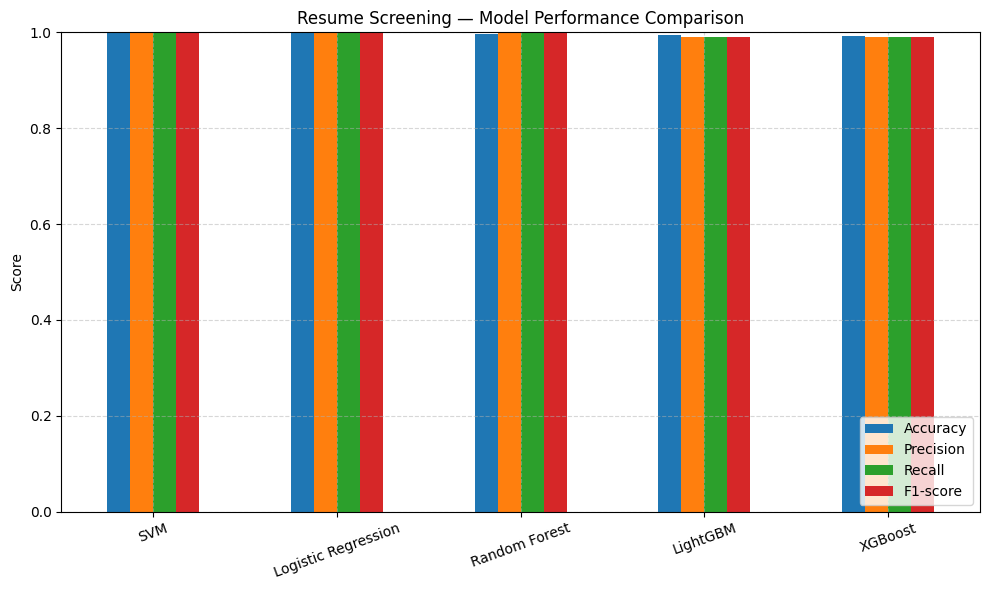

In [14]:
# ============================================================
# STEP 9 — MODEL PERFORMANCE COMPARISON (PLOT)
# ============================================================

results_df = pd.DataFrame(model_results).T.sort_values("Accuracy", ascending=False)

print("\n=== Model Performance Summary ===")
print(results_df)

results_df.plot(kind="bar", figsize=(10, 6))
plt.title("Resume Screening — Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.0)
plt.xticks(rotation=20)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=120)
plt.show()


In [15]:
# ============================================================
# STEP 10 — BEST MODEL SELECTION (Weighted Score)
# ============================================================

best_model_name = max(
    model_results,
    key=lambda k: (
        0.25 * model_results[k]["Accuracy"] +
        0.25 * model_results[k]["Precision"] +
        0.25 * model_results[k]["Recall"] +
        0.25 * model_results[k]["F1-score"]
    )
)

best_model = models[best_model_name]

print(f"\n✅ Best Model Selected: {best_model_name}")
print(f"   Accuracy:  {model_results[best_model_name]['Accuracy']}")
print(f"   Precision: {model_results[best_model_name]['Precision']}")
print(f"   Recall:    {model_results[best_model_name]['Recall']}")
print(f"   F1-score:  {model_results[best_model_name]['F1-score']}")



✅ Best Model Selected: SVM
   Accuracy:  0.999
   Precision: 1.0
   Recall:    1.0
   F1-score:  1.0


In [16]:
# ============================================================
# STEP 11 — SAVE MODEL, TFIDF, LABEL ENCODER
# ============================================================

pickle.dump(best_model, open("model.pkl", "wb"))
pickle.dump(tfidf,      open("tfidf.pkl", "wb"))
joblib.dump(le,                "label_encoder.pkl")

print("\n✅ Saved: model.pkl | tfidf.pkl | label_encoder.pkl")



✅ Saved: model.pkl | tfidf.pkl | label_encoder.pkl


In [18]:
# ============================================================
# STEP 12 — FILE TEXT EXTRACTION (PDF / DOCX / IMAGE)
# ============================================================

def extract_pdf(file_path):
    """PDF se text extract karta hai"""
    doc = fitz.open(str(file_path))
    text = []

    for page in doc:
        text.append(page.get_text())

    return " ".join(text)


def extract_docx(file_path):
    """Word document text extract"""
    doc = docx.Document(file_path)
    text = "\n".join([p.text for p in doc.paragraphs])
    return text


def extract_image(file_path):
    """Image OCR  text extract"""
    img = Image.open(file_path)
    text = pytesseract.image_to_string(img.convert("L"))
    return text


def read_resume(file_path):
    """File type detect"""
    ext = file_path.lower()

    if ext.endswith(".pdf"):
        return extract_pdf(file_path)
    elif ext.endswith(".docx"):
        return extract_docx(file_path)
    elif ext.endswith((".png", ".jpg", ".jpeg")):
        return extract_image(file_path)
    else:
        return "Unsupported file format"


In [19]:
# ============================================================
# STEP 13 — HR JOB MATCHING SYSTEM
# ============================================================

def recommend_jobs(resume_text):

    cleaned_resume = clean_text(resume_text)

    resume_vector = tfidf.transform([cleaned_resume])

    similarities = cosine_similarity(
        resume_vector,
        job_vectors
    )[0]

    results = []

    for i, score in enumerate(similarities):

        results.append({
            "Job": job_titles[i],
            "Match": round(score * 100, 2)
        })

    results = sorted(
        results,
        key=lambda x: x["Match"],
        reverse=True
    )

    return results

In [20]:
# ============================================================
# STEP 13.5 — HR DECISION SYSTEM
# ============================================================

def hr_decision_system(resume_text):

    matches = recommend_jobs(resume_text)

    print("\n===== HR MATCHING REPORT =====")

    recommended_jobs = []

    for item in matches:

        print(
            f"{item['Job']} --> {item['Match']}%"
        )

        if item["Match"] >= 60:
            recommended_jobs.append(item)

    print("\n===== RECOMMENDED JOBS =====")

    if len(recommended_jobs) == 0:

        print(
            "No job crossed 60% threshold"
        )

    else:

        for job in recommended_jobs:

            print(
                f"✅ {job['Job']} ({job['Match']}%)"
            )

    return recommended_jobs

In [21]:
# ============================================================
# STEP 14 — RESUME EVALUATION
# ============================================================

def predict_resume(file_path):

    try:

        # Resume read karo
        resume_text = read_resume(file_path)

        # Empty file check
        if not resume_text.strip():

            print("❌ Empty Resume")

            return

        print("\n" + "="*70)
        print("RESUME EVALUATION REPORT")
        print("="*70)

        # HR Matching Report
        hr_decision_system(resume_text)

    except Exception as e:

        print(
            f"❌ Error occurred: {str(e)}"
        )

In [22]:
# ============================================================
# TEST SINGLE RESUME
# ============================================================

predict_resume("resume.pdf")

❌ Error occurred: no such file: 'resume.pdf'


In [23]:
# ============================================================
# STEP 15 — BATCH RESUME SCREENING
# ============================================================

def run_batch_prediction():

    import os

    print("📂 Upload Candidate Resumes")
    print("Supported: PDF, DOCX, PNG, JPG")

    uploaded = files.upload()

    for file_name in uploaded.keys():

        print("\n" + "="*70)

        candidate_name = os.path.splitext(file_name)[0]

        candidate_name = (
            candidate_name
            .replace("_", " ")
            .replace("-", " ")
            .title()
        )

        print(f"Candidate: {candidate_name}")

        file_path = "/content/" + file_name

        try:

            resume_text = read_resume(file_path)

            if not resume_text.strip():

                print("❌ Resume text extract nahi hua")
                continue

            hr_decision_system(resume_text)

        except Exception as e:

            print("❌ Error:", e)

        print("="*70)

In [24]:
# ============================================================
# RUN BATCH SCREENING
# ============================================================

run_batch_prediction()

ModuleNotFoundError: No module named 'google.colab'

In [25]:
# ============================================================
# STEP 16 — TEST SYSTEM
# ============================================================

sample_resumes = {

    "Ali Ahmed": """
    Python Machine Learning Deep Learning TensorFlow
    PyTorch Statistics SQL NLP Computer Vision
    Data Science Pandas NumPy
    """,

    "Sara Khan": """
    SQL Excel Tableau Power BI
    Dashboard Reporting Data Visualization
    Business Intelligence ETL
    """,

    "Usman Raza": """
    Python Java C++ JavaScript React NodeJS
    Data Structures Algorithms OOP
    REST API Git Software Development
    """,

    "Ayesha Malik": """
    Python MLOps Docker Kubernetes AWS
    TensorFlow PyTorch MLflow
    Model Deployment CI CD
    """
}

print("\n" + "="*70)
print("AI-POWERED HR RECRUITMENT SYSTEM")
print("="*70)

for name, text in sample_resumes.items():

    print("\n" + "="*70)
    print(f"Candidate: {name}")
    print("="*70)

    hr_decision_system(text)

    print("\n")


AI-POWERED HR RECRUITMENT SYSTEM

Candidate: Ali Ahmed

===== HR MATCHING REPORT =====
Data Scientist --> 83.98%
Machine Learning Engineer --> 36.11%
Software Engineer --> 8.87%
Data Analyst --> 6.7%

===== RECOMMENDED JOBS =====
✅ Data Scientist (83.98%)



Candidate: Sara Khan

===== HR MATCHING REPORT =====
Data Analyst --> 89.43%
Data Scientist --> 6.18%
Software Engineer --> 2.88%
Machine Learning Engineer --> 0.0%

===== RECOMMENDED JOBS =====
✅ Data Analyst (89.43%)



Candidate: Usman Raza

===== HR MATCHING REPORT =====
Software Engineer --> 88.84%
Data Scientist --> 7.27%
Machine Learning Engineer --> 6.91%
Data Analyst --> 2.56%

===== RECOMMENDED JOBS =====
✅ Software Engineer (88.84%)



Candidate: Ayesha Malik

===== HR MATCHING REPORT =====
Machine Learning Engineer --> 88.72%
Data Scientist --> 15.41%
Software Engineer --> 8.77%
Data Analyst --> 0.0%

===== RECOMMENDED JOBS =====
✅ Machine Learning Engineer (88.72%)




In [26]:
import sys
!{sys.executable} -m pip install streamlit


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\PMYLS\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [27]:
import streamlit as st
import pickle
import joblib
import re
import fitz
import docx

from PIL import Image
import pytesseract

from sklearn.metrics.pairwise import cosine_similarity

# ==========================================================
# LOAD TF-IDF
# ==========================================================

tfidf = pickle.load(open("tfidf.pkl", "rb"))

# ==========================================================
# HR JOB OPENINGS
# ==========================================================

job_openings = {

    "Data Scientist": """
    Python Machine Learning Deep Learning TensorFlow
    PyTorch Statistics SQL NLP Computer Vision
    Data Analysis Pandas NumPy
    """,

    "Machine Learning Engineer": """
    Python MLOps Docker Kubernetes AWS
    TensorFlow PyTorch Model Deployment
    CI CD MLflow
    """,

    "Data Analyst": """
    SQL Excel Tableau Power BI
    Data Visualization Dashboard Reporting
    ETL Business Intelligence
    """,

    "Software Engineer": """
    Python Java C++
    JavaScript React NodeJS
    Data Structures Algorithms
    OOP REST API Git
    """
}

# ==========================================================
# STOPWORDS
# ==========================================================

STOP_WORDS = {
    "a","an","the","and","or","but","in","on","at","to","for","of",
    "with","is","are","was","were","be","been","being","have","has",
    "had","do","does","did","will","would","could","should","may",
    "might","shall","can","need","it","its","this","that"
}

# ==========================================================
# TEXT CLEANING
# ==========================================================

def clean_text(text):

    if not text:
        return ""

    text = text.lower()

    text = re.sub(
        r"[^a-zA-Z\s]",
        "",
        text
    )

    words = text.split()

    words = [
        word
        for word in words
        if word not in STOP_WORDS
    ]

    return " ".join(words)

# ==========================================================
# CREATE JOB VECTORS
# ==========================================================

job_titles = list(job_openings.keys())

job_descriptions = [
    clean_text(desc)
    for desc in job_openings.values()
]

job_vectors = tfidf.transform(
    job_descriptions
)

# ==========================================================
# FILE EXTRACTION
# ==========================================================

def extract_pdf(file):

    doc = fitz.open(
        stream=file.read(),
        filetype="pdf"
    )

    text = ""

    for page in doc:
        text += page.get_text()

    return text


def extract_docx(file):

    doc = docx.Document(file)

    text = "\n".join(
        [p.text for p in doc.paragraphs]
    )

    return text


def extract_image(file):

    image = Image.open(file)

    text = pytesseract.image_to_string(
        image
    )

    return text


def read_resume(file):

    name = file.name.lower()

    if name.endswith(".pdf"):
        return extract_pdf(file)

    elif name.endswith(".docx"):
        return extract_docx(file)

    elif name.endswith(
        (".png", ".jpg", ".jpeg")
    ):
        return extract_image(file)

    return ""

# ==========================================================
# HR MATCHING FUNCTION
# ==========================================================

def match_jobs(resume_text):

    cleaned_resume = clean_text(
        resume_text
    )

    resume_vector = tfidf.transform(
        [cleaned_resume]
    )

    similarities = cosine_similarity(
        resume_vector,
        job_vectors
    )[0]

    results = []

    for i, score in enumerate(
        similarities
    ):

        results.append(
            (
                job_titles[i],
                round(score * 100, 2)
            )
        )

    results.sort(
        key=lambda x: x[1],
        reverse=True
    )

    return results

# ==========================================================
# STREAMLIT UI
# ==========================================================

st.set_page_config(
    page_title="HR Recruitment System",
    page_icon="💼"
)

st.title(
    "💼 AI-Powered HR Recruitment System"
)

st.write(
    "Upload Resume and Check Job Matching"
)

uploaded_file = st.file_uploader(
    "Upload Resume",
    type=[
        "pdf",
        "docx",
        "png",
        "jpg",
        "jpeg"
    ]
)

# ==========================================================
# MAIN LOGIC
# ==========================================================

if uploaded_file:

    resume_text = read_resume(
        uploaded_file
    )

    if not resume_text.strip():

        st.error(
            "Could not extract text from file"
        )

    else:

        results = match_jobs(
            resume_text
        )

        st.subheader(
            "📊 HR Matching Report"
        )

        for role, match in results:

            st.write(
                f"**{role}** → {match}%"
            )

            st.progress(
                min(int(match), 100)
            )

            if match >= 60:

                st.success(
                    f"✅ Recommended for {role}"
                )

            else:

                st.warning(
                    f"❌ Below 60% Threshold"
                )

        # ===================================
        # BEST MATCH
        # ===================================

        best_role = results[0][0]
        best_score = results[0][1]

        st.markdown("---")

        st.subheader(
            "🎯 Final HR Decision"
        )

        if best_score >= 60:

            st.success(
                f"""
                Candidate is Recommended

                Job Role: {best_role}

                Match Score: {best_score}%
                """
            )

        else:

            st.error(
                f"""
                Candidate Not Recommended

                Highest Match:
                {best_role}

                Score:
                {best_score}%
                """
            )

2026-06-14 06:24:45.504 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-14 06:24:45.506 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-14 06:24:45.781 
  command:

    streamlit run C:\Users\PMYLS\AppData\Local\Programs\Python\Python312\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-06-14 06:24:45.781 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-14 06:24:45.782 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-14 06:24:45.783 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-14 06:24:45.785 Thread 'MainThread': missing ScriptRunContext! This wa

In [44]:
print(os.listdir())

['(76323).ipynb', '.android', '.emulator_console_auth_token', '.gradle', '.idea', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.nlogo', '.node_repl_history', '.openjfx', '.packettracer', '.streamlit', '3D Objects', 'AndroidStudioProjects', 'App', 'app.py', 'AppData', 'Application Data', 'ARooj(76323).ipynb', 'Assignment statistic.ipynb', 'bmi_validation.csv', 'breast-cancer.csv', 'Cisco Packet Tracer 7.3.0', 'Class1AI.ipynb', 'cleaned_student_data.csv', 'Contacts', 'Cookies', 'Credit Requirement Event Logs_1_all.zip', 'CreditRequirement.mxml', 'data.xlsx - Data.csv', 'Desktop', 'Diabetes Classification.csv', 'directed_workflow_graph.png', 'Documents', 'Downloads', 'eda_age_distribution.png', 'eda_gender_distribution.png', 'eda_job_distribution.png', 'eda_length_distribution.png', 'eda_top_jd_words.png', 'eda_top_resume_words.png', 'Favorites', 'fig1_main_network.png', 'fig2_centrality_bars.png', 'fixed_workflow_graph.png', 'Fluxicon', 'HeartDesease_Predictio